In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# orders_qu.csv
url = "https://drive.google.com/file/d/143CzG5DriVSPMkaL1UP4k3Y80oS8fgbV/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qu = pd.read_csv(path)
orders_qu['created_date'] = pd.to_datetime(orders_qu['created_date'])

# orderlines_qu.csv
url = "https://drive.google.com/file/d/1yWO-mQfxQtnSZdCgdNlIEUrZSCW1HN5O/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands.csv
url = "https://drive.google.com/file/d/1XGyabaa4mAkjixMk3XPgx_14OoSse3rs/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

# merged tables
prods_orderlines_qu = pd.merge(orderlines_qu, products_cl, on='sku', how='left').copy()
prods_orderlines_qu['date'] = pd.to_datetime(prods_orderlines_qu['date'])

# EXTRA COLUMNS
prods_orderlines_qu['discount'] = prods_orderlines_qu['price']-prods_orderlines_qu['unit_price']
prods_orderlines_qu['revenue'] = prods_orderlines_qu['unit_price'] * prods_orderlines_qu['product_quantity']
prods_orderlines_qu['percentage_discount'] = round(100 * (prods_orderlines_qu['price'] - prods_orderlines_qu['unit_price']) / prods_orderlines_qu['price'], 2)

prods_orderlines_qu = prods_orderlines_qu.merge(
    orders_qu[['order_id', 'state']],
    left_on='id_order',   # Name in prods_orderlines_qu
    right_on='order_id',  # Name in orders_qu
    how='left'
)

Discounted vs Non-Discounted Products

In [3]:
discounted_prods = prods_orderlines_qu.loc[prods_orderlines_qu['discount'] != 0, 'sku'] #.count()
not_discounted_prods = prods_orderlines_qu.loc[prods_orderlines_qu['discount'] == 0, 'sku'] #.count()

#not_discounted_prods
#discounted_prods

In [4]:
# non-discounted products table

prods_orderlines_qu.loc[prods_orderlines_qu['discount'] == 0, ['name','price', 'unit_price', 'discount']].sort_values(by='price', ascending=False)

,name,price,unit_price,discount
13681,"LG 34UC99-W Monitor 34 ""WQHD Curvy USB-C 5ms M...",999.00,999.00,0.0
767,"Apple iPad Pro 9.7 ""Wi-Fi + Cellular 128GB Spa...",939.00,939.00,0.0
8810,"Apple iPad Pro 9.7 ""Wi-Fi + Cellular 128GB Silver",939.00,939.00,0.0
17546,"Apple iPad Pro 12.9 ""Wi-Fi 64GB Silver",899.00,899.00,0.0
14249,G-Technology G-RAID Thunderbolt 12TB Extraible...,839.99,839.99,0.0
...,...,...,...,...
48771,iFixit Demagnetizer / Magnetizer,3.99,3.99,0.0
42650,iFixit Demagnetizer / Magnetizer,3.99,3.99,0.0
51418,iFixit Demagnetizer / Magnetizer,3.99,3.99,0.0
11477,iFixit Demagnetizer / Magnetizer,3.99,3.99,0.0


In [5]:
#discounted products table

prods_orderlines_qu.loc[prods_orderlines_qu['discount'] != 0, ['name','price', 'unit_price', 'discount', 'date']].sort_values(by='discount', ascending=False)

,name,price,unit_price,discount,date
17953,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz...",1799.0,479.00,1320.00,2017-07-26 19:41:00
13472,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz...",1799.0,489.00,1310.00,2017-06-11 12:34:44
12109,"Second hand - Apple iMac 24 ""Core 2 Duo 28 GHz...",1799.0,499.00,1300.00,2017-05-20 07:18:41
28993,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz...",1499.0,255.59,1243.41,2017-11-14 12:47:25
26226,"Second hand - Apple iMac 20 ""Core 2 Duo 266GHz...",1499.0,335.59,1163.41,2017-10-23 00:51:52
...,...,...,...,...,...
20269,Apple iPhone 32GB Rose Gold 7,639.0,770.33,-131.33,2017-08-20 16:15:13
20671,Apple iPhone 7 128GB Black Bright,749.0,880.33,-131.33,2017-08-24 19:52:21
19059,Apple iPhone 6s 128GB Rose Gold,639.0,770.33,-131.33,2017-08-04 15:44:45
1245,12TB LaCie 2big Thunderbolt 2,719.0,889.99,-170.99,2017-01-07 10:13:51


Pie chart for discounted vs non-discounted products

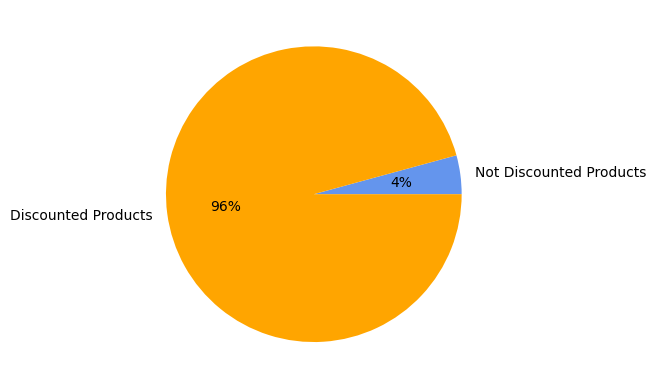

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

discounted_prods = prods_orderlines_qu.loc[prods_orderlines_qu['discount'] != 0, 'sku'].count()
not_discounted_prods = prods_orderlines_qu.loc[prods_orderlines_qu['discount'] == 0, 'sku'].count()

not_discounted_prods
discounted_prods

data = [2256, 50975]
labels = ['Not Discounted Products', 'Discounted Products']
colors= ('cornflowerblue', 'orange')

plt.pie(data, labels=labels, colors=colors, autopct='%.0f%%')
plt.show()

Plot: Revenue vs Discount

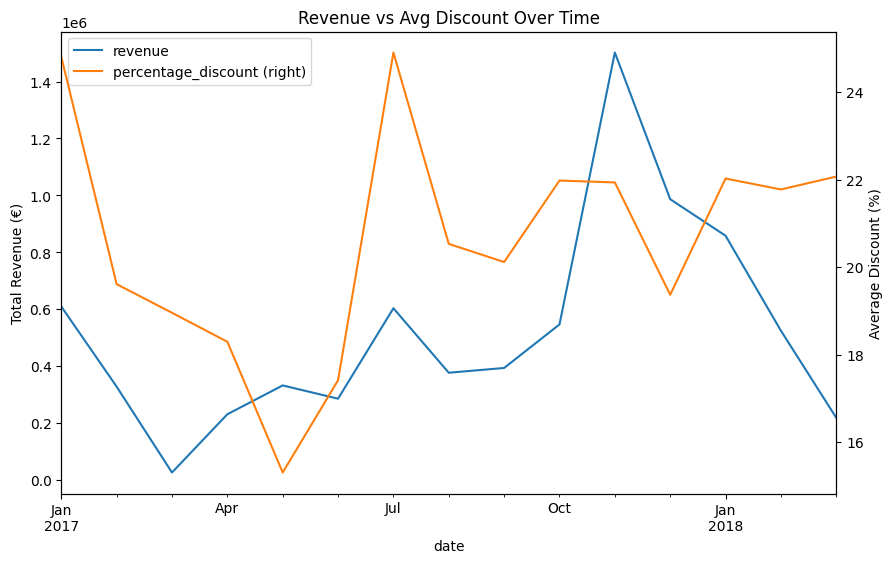

In [7]:
ax = prods_orderlines_qu.resample('ME', on='date').agg({
    'revenue': 'sum',
    'percentage_discount': 'mean'
}).plot(secondary_y=['percentage_discount'], figsize=(10, 6), title='Revenue vs Avg Discount Over Time', );

# 2. Set the Left Y-Axis Label
ax.set_ylabel("Total Revenue (€)")

# 3. Set the Right Y-Axis Label
# ax.right_ax is created automatically by pandas when secondary_y=True
ax.right_ax.set_ylabel("Average Discount (%)");

Percentages and Discounts

In [8]:
# COMPLETED & PERCENTAGES MASKS
completed = prods_orderlines_qu.loc[prods_orderlines_qu['state'] == 'Completed']
five_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 5]
ten_percent= prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 10]
fifteen_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 15]
twenty_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 20]
twentyfive_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 25]
thirty_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 30]
fourty_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 40]
fifty_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 50]
sixty_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 60]
seventy_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 70]
eighty_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 80]
ninety_percent = prods_orderlines_qu.loc[prods_orderlines_qu['percentage_discount'] == 90]


# INTERSECTIONS OF COMPLETED ORDERS + OFFERED DISCOUNT
prods_orderlines_qu.loc[completed.index.intersection(five_percent.index)].count() # 301 completed orders with 5% discount
prods_orderlines_qu.loc[completed.index.intersection(ten_percent.index)].count() # 477 completed orders with 10% discount
prods_orderlines_qu.loc[completed.index.intersection(fifteen_percent.index)].count() # 155 completed orders with 15% discount
prods_orderlines_qu.loc[completed.index.intersection(twenty_percent.index)].count() # 875 completed orders with 20% discount
prods_orderlines_qu.loc[completed.index.intersection(twentyfive_percent.index)].count() # 333 completed with 25% discount
prods_orderlines_qu.loc[completed.index.intersection(thirty_percent.index)].count() # 51 completed with 30% discount
prods_orderlines_qu.loc[completed.index.intersection(fourty_percent.index)].count() # 89 completed with 40% discount
prods_orderlines_qu.loc[completed.index.intersection(fifty_percent.index)].count() # 15 completed with 50% discount
prods_orderlines_qu.loc[completed.index.intersection(sixty_percent.index)].count() # 0 completed with 60% discount
prods_orderlines_qu.loc[completed.index.intersection(seventy_percent.index)].count() # 0 completed with 70% discount
prods_orderlines_qu.loc[completed.index.intersection(eighty_percent.index)].count() # 0 completed with 80% discount
prods_orderlines_qu.loc[completed.index.intersection(ninety_percent.index)].count() # 0 completed with 90% discount

,0
id,0
id_order,0
product_id,0
product_quantity,0
sku,0
unit_price,0
date,0
name,0
desc,0
price,0


In [9]:
# calculating revenue for completed orders with 20% discount

completed_twenty_percent = prods_orderlines_qu.loc[(prods_orderlines_qu['state'] == 'Completed') & (prods_orderlines_qu['percentage_discount'] == 20)]

round(completed_twenty_percent['revenue'].sum(),2)

np.float64(78125.98)

Plot for Discounts

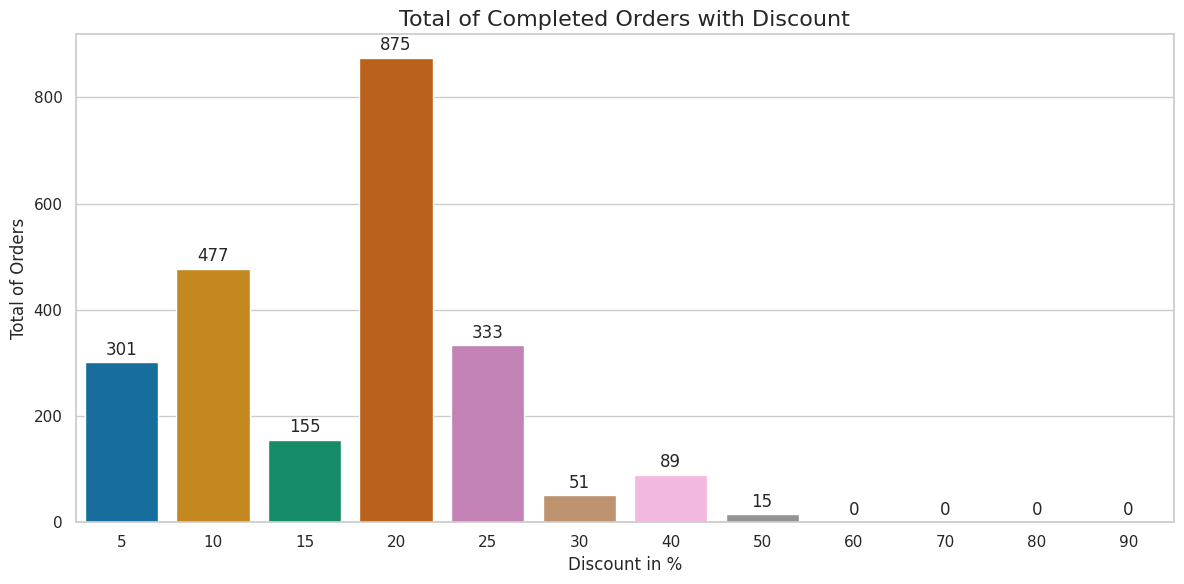

In [10]:

# dictionary for the data
data = {
    'Discount (%)': [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90],
    'Completed Orders': [301, 477, 155, 875, 333, 51, 89, 15, 0, 0, 0, 0]
}

# pandas dataframe creation
df = pd.DataFrame(data)

# seaborn design
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# plot creation
barplot = sns.barplot(x='Discount (%)',
    y='Completed Orders',
    data=df,
    palette='colorblind',
    hue='Discount (%)',
    legend=False
)

# titles
plt.title('Total of Completed Orders with Discount', fontsize=16)
plt.xlabel('Discount in %', fontsize=12)
plt.ylabel('Total of Orders', fontsize=12)

# values above the bar bins for improved readability
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

### Black Friday plots

Pandas plot

The highest point in this plot is the 24th November, which was Black Friday in 2017.


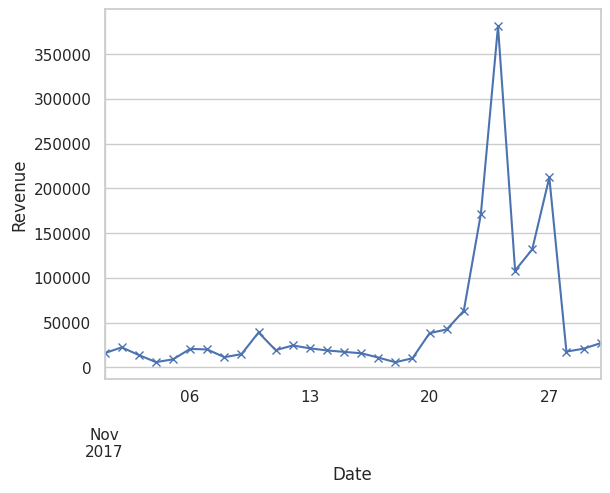

In [11]:
black_friday_frame = orders_qu.loc[orders_qu['created_date'].between('2017-11-01', '2017-12-01')]

black_friday_frame.set_index('created_date')['total_paid'].resample('D').sum().plot(xlabel='Date', ylabel='Revenue', marker='x');

print('The highest point in this plot is the 24th November, which was Black Friday in 2017.')

Seaborn Plot

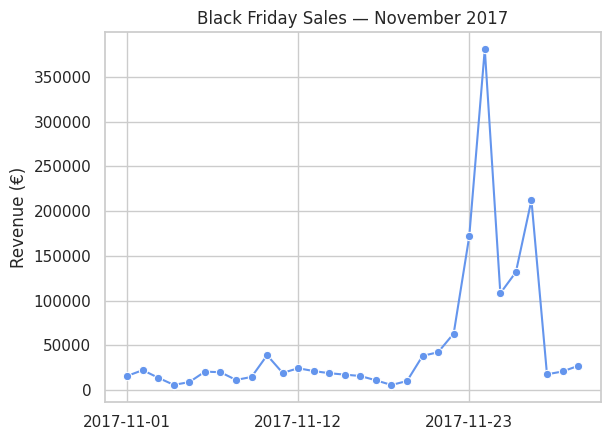

In [12]:
### BLACK FRIDAY PLOT ###
mask1 = (orders_qu['created_date'].between('2017-11-01', '2017-12-01')) & \
       (orders_qu['state'] == 'Completed')

# Filtering
black_friday_completed = orders_qu.loc[mask1]

# resampling and preparation
daily_revenue = (
    black_friday_completed
    .set_index('created_date')['total_paid']
    .resample('D')
    .sum()
    .reset_index()
)

# Seaborn Plot
black_friday_plot = sns.lineplot(
    data=daily_revenue,
    x='created_date',
    y='total_paid',
    marker='o',
    color='cornflowerblue'
);

black_friday_plot.set(xticks=daily_revenue['created_date'][::11])


black_friday_plot.set_ylabel('Revenue (€)')
black_friday_plot.set_xlabel('')
black_friday_plot.set(title='Black Friday Sales — November 2017');

Total Revenue Black Friday

In [13]:
mask_revenue_bf = (orders_qu['created_date'].between('2017-11-24', '2017-11-25')) & \
              (orders_qu['state'] == 'Completed')

total_rev_bf = orders_qu.loc[mask_revenue_bf, 'total_paid'].sum()

print(f'The total revenue on Black Friday (24/11/2017) is {total_rev_bf:,.2f}€.')

The total revenue on Black Friday (24/11/2017) is 381,007.67€.


### Christmas Plots

Pandas Plot

The highest point in this plot is the 13th of December with over 1.4 million € revenue with rising fluctuations before that. 
Right after, the revenue falls shortly before Christmas. 
After Christmas there is a smaller peak, which indicates a sort of "Post Christmas Sale".


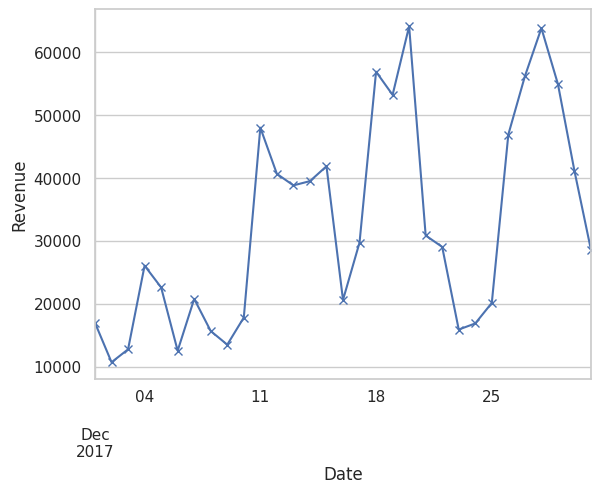

In [14]:
christmas_frame = orders_qu.loc[orders_qu['created_date'].between('2017-12-01', '2018-01-01')]

christmas_frame.set_index('created_date')['total_paid'].resample('D').sum().plot(xlabel='Date', ylabel='Revenue', marker='x');

print('The highest point in this plot is the 13th of December with over 1.4 million € revenue with rising fluctuations before that. \nRight after, the revenue falls shortly before Christmas. \nAfter Christmas there is a smaller peak, which indicates a sort of "Post Christmas Sale".')

Seaborn Plot

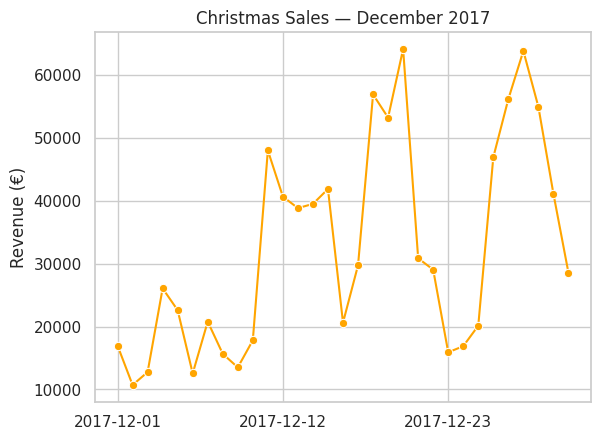

In [15]:
### CHRISTMAS PLOT ###

mask2 = (orders_qu['created_date'].between('2017-12-01', '2018-01-01')) & \
       (orders_qu['state'] == 'Completed')

# Filtering
christmas_completed = orders_qu.loc[mask2]

# resampling and preparation
daily_revenue = (
    christmas_completed
    .set_index('created_date')['total_paid']
    .resample('D')
    .sum()
    .reset_index()
)

# Seaborn Plot
christmas_plot = sns.lineplot(
    data=daily_revenue,
    x='created_date',
    y='total_paid',
    marker='o',
    color='orange'
);

christmas_plot.set(xticks=daily_revenue['created_date'][::11])


christmas_plot.set_ylabel('Revenue (€)')
christmas_plot.set_xlabel('')
christmas_plot.set(title='Christmas Sales — December 2017');

#plt.savefig("christmas_plot.png", dpi=300, bbox_inches='tight')

Total Revenue Christmas

In [16]:
mask_revenue_christmas = (orders_qu['created_date'].between('2017-12-01', '2018-01-01')) & \
              (orders_qu['state'] == 'Completed')

total_rev_christmas = orders_qu.loc[mask_revenue_christmas, 'total_paid'].sum()

print(f'The total revenue during Christmas time is {total_rev_christmas:,.2f}€.')

The total revenue during Christmas time is 1,007,358.85€.


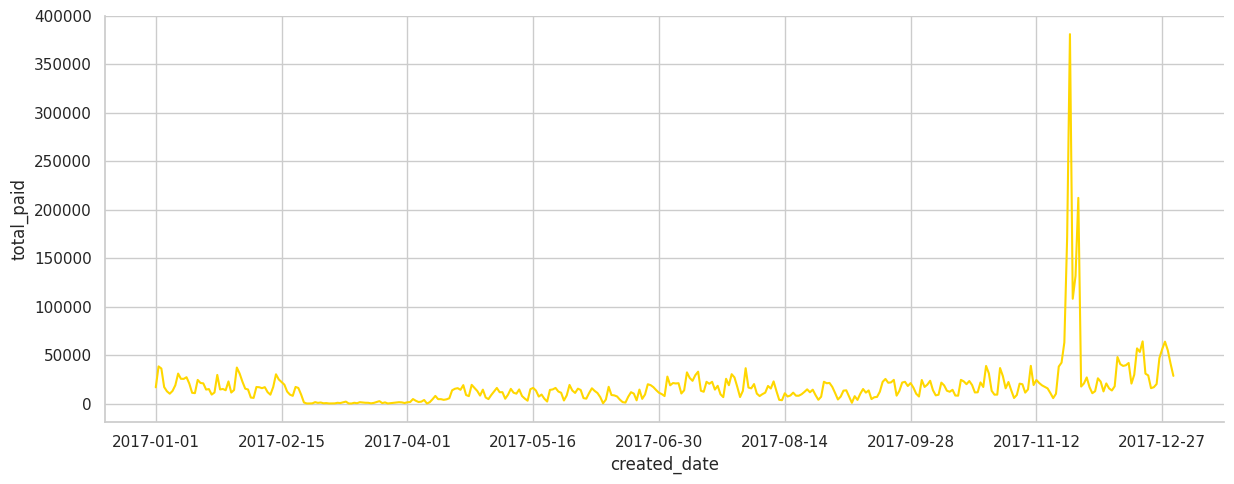

In [17]:
### WHOLE YEAR PLOT ###

mask2 = (orders_qu['created_date'].between('2017-01-01', '2018-01-01')) & \
       (orders_qu['state'] == 'Completed')

# Filtering
year_completed = orders_qu.loc[mask2]

# resampling and preparation
daily_revenue = (
    year_completed
    .set_index('created_date')['total_paid']
    .resample('D')
    .sum()
    .reset_index()
)

# Seaborn Plot
year_plot = sns.relplot(
    kind='line',
    data=daily_revenue,
    x='created_date',
    y='total_paid',
    #marker='o',
    color='gold',
    aspect=2.5
)

year_plot.set(xticks=daily_revenue['created_date'][::45]);


#plt.savefig("christmas_plot.png", dpi=300, bbox_inches='tight')